<a href="https://colab.research.google.com/github/dhanwariagarvit21/cont-s-stylized-facts/blob/main/intermittency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
import scipy.stats as stats
import statsmodels.api as sm
import os

In [42]:
path = kagglehub.dataset_download("debashis74017/nifty-50-minute-data")
print("Path to dataset files:", path)
file_name = 'NIFTY 50_minute.csv'
full_file_path = os.path.join(path, file_name)
data_f = pd.read_csv(full_file_path)

Using Colab cache for faster access to the 'nifty-50-minute-data' dataset.
Path to dataset files: /kaggle/input/nifty-50-minute-data


In [43]:
data_f['log_return'] = np.log(data_f['close']/data_f['close'].shift(1))
data_f = data_f.dropna()

In [44]:
def acf_plot(data_f):
  lags = 200
  acf_raw = acf(data_f['log_return'], nlags=lags)
  acf_abs = acf(data_f['log_return'].abs(), nlags=lags)
  plt.figure(figsize=(10, 4))
  plt.plot(acf_raw, label='Raw Returns r_t (No Correlation)', alpha=0.7)
  plt.plot(acf_abs, label='Absolute Returns |r_t| (Volatility Persistence)', color='red')
  plt.axhline(0, linestyle='--', color='gray')
  plt.title('Autocorrelation Function: Raw vs Absolute Returns')
  plt.legend()
  plt.show()

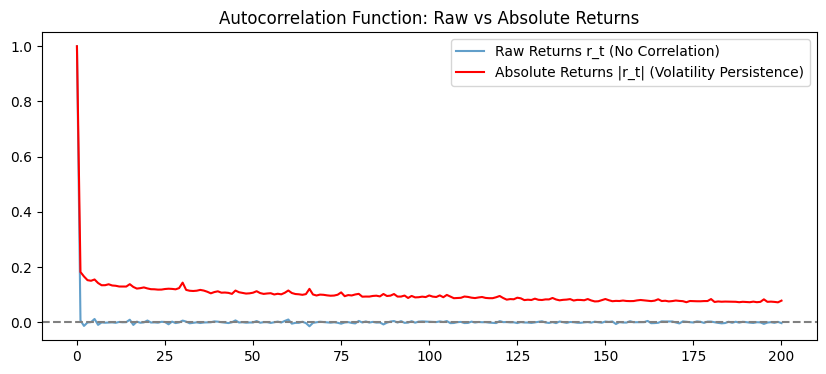

None


In [45]:
print(acf_plot(data_f))

In [46]:
def intermittancy(df):
  time_scales = [1, 2, 4, 8, 16, 32, 64]
  q_orders = [1, 2, 3, 4]
  fig, axes = plt.subplots(1, 2, figsize=(14, 7))

  scaling_results = {q: [] for q in q_orders}

  for scale in time_scales:
      agg_returns = df['log_return'].rolling(window=scale).sum().dropna()
      for q in q_orders:
          moment = np.mean(np.abs(agg_returns)**q)
          scaling_results[q].append(moment)
  zeta = []
  for q in q_orders:
      slope, _ = np.polyfit(np.log(time_scales), np.log(scaling_results[q]), 1)
      zeta.append(slope)
  print("Scaling exponents zeta(q):", dict(zip(q_orders, zeta)))
  axes[0].plot(q_orders, zeta, 'o-', color='#2ca02c', lw=2, label='Empirical Nifty 50')
  axes[0].plot(q_orders, np.array(q_orders) / 2.0, '--', color='black', label='Monofractal / Gaussian (q/2)')
  axes[0].set_title('1. Multifractal Structure Function Scaling', fontweight='bold')
  axes[0].set_xlabel('Moment Order q')
  axes[0].set_ylabel('Scaling Exponent zeta(q)')
  axes[0].legend()
  axes[0].grid(True, linestyle='--', alpha=0.5)

  x = np.linspace(-0.04, 0.04, 200)
  axes[1].hist(df['log_return'], bins=100, density=True, alpha=0.5, color='#1f77b4', label='50-min Returns')
  axes[1].plot(x, stats.norm.pdf(x, df['log_return'].mean(), df['log_return'].std()), color='navy', linestyle='--', label='Gaussian Fit')
  axes[1].set_yscale('log')
  axes[1].set_title('2. Fat-Tails (Log Density Plot)', fontweight='bold')
  axes[1].set_xlabel('Log Return')
  axes[1].set_ylabel('Probability Density (Log Scale)')
  axes[1].set_xlim(-0.04, 0.04)
  axes[1].legend()
  axes[1].grid(True, linestyle='--', alpha=0.5)

  plt.tight_layout()
  plt.show()

Scaling exponents zeta(q): {1: np.float64(0.5412730585577687), 2: np.float64(1.000019475497432), 3: np.float64(1.1139503730117104), 4: np.float64(1.1610761741647564)}


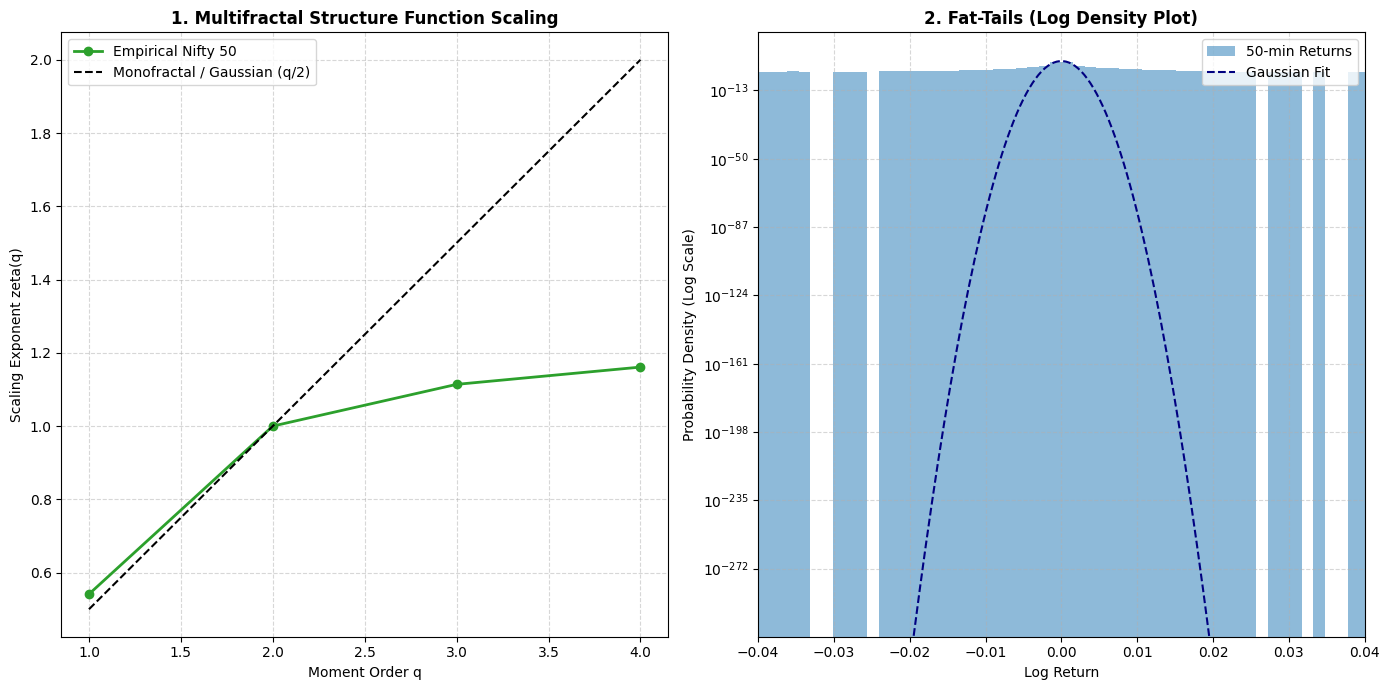

None


In [47]:
print(intermittancy(data_f))